In [1]:
import osmnx as ox
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt 
from shapely.geometry import box
from sklearn.neighbors import BallTree

import seaborn as sns
import numpy as np
from geopy.geocoders import Nominatim
import time
from shapely.geometry import Point


In [3]:
#Importing requirement dataset

#Load data map Provinsi Jawa Barat

map_path = "indonesia-province.json"
map_df = gpd.read_file(map_path)
map_df.head()

# Visualisasi peta Jawa Barat
jabar_map = map_df[map_df['Propinsi'].str.contains('JAWA BARAT', case=False, na=False)].copy() 
jabar_map = jabar_map.to_crs(epsg=4326)



Kolom yang tersedia di jabar_map: Index(['ID', 'kode', 'Propinsi', 'SUMBER', 'geometry'], dtype='object')


In [ ]:
#Load dataframe
df_poi = pd.read_csv("data/osmnx_data/data_titik_poi_lengkap_jabar.csv") #Aman 
data_kependudukan = pd.read_csv('data/data_general/kepadatan_penduduk.csv')

df_bps_last = df_bps[df_bps['tahun'] == df_bps['tahun'].max()].copy()
df_bps_last['nama_kabupaten_kota'] = df_bps_last['nama_kabupaten_kota'].str.upper().str.strip()
df_poi['nama_kabupaten_kota'] = df_poi['nama_kabupaten_kota'].str.upper().str.strip()]



,nama_kabupaten_kota,kepadatan_penduduk
189,KABUPATEN BOGOR,1912
190,KABUPATEN SUKABUMI,685
191,KABUPATEN CIANJUR,719
192,KABUPATEN BANDUNG,2173
193,KABUPATEN GARUT,886


In [ ]:
#Proses pembuatan data koordinat  untuk wilayah Jawa Barat
#INI JANGAN DI RUN SEMBARANGAN!
utara, selatan, timur, barat = -5.9, -7.8, 108.8, 106.3
bbox_jabar = box(barat, selatan, timur, utara)

#Dictionary buat kategori yang mau diunduh datanya dari osm 
categories = {
    "halte": {"amenity": [ "college", "university"]}
}

# Fungsi untuk mengunduh data poi berdasarkan kategori dan area dan mengambil longitude dan latitude dari centroid geometry
def get_poi_data(categories_dict, polygon_area):
    all_results = {}

    for name, tags in categories_dict.items():
        try:
            print(f"Lagi ngunduh data {name}..." )

            poi = ox.features_from_polygon(polygon=polygon_area, tags=tags)
            
            if not poi.empty:
                poi = poi[poi.geometry.notnull()].copy()

                poi['lat'] = poi.geometry.centroid.y
                poi['lon'] = poi.geometry.centroid.x
                poi['kategori'] = name

                df_result = poi[['lat', 'lon', 'kategori']].reset_index(drop=True)
                all_results[name] = df_result

                filename = f"data_titik_{name}_jabar.csv"
                df_result.to_csv(filename, index=False)
            else:
                print(f"Tidak ada data ditemukan untuk {name}")
        except Exception as e:
            print(f"Gagal mengunduh data untuk {name}: {e}")
            
    return all_results

download_results = get_poi_data(categories, bbox_jabar)

if download_results:
    df_final = pd.concat(download_results.values(), ignore_index=True)
    df_final.to_csv("data_titik_poi_lengkap_jabar.csv", index=False)
    print("\n" + "="*30)
    print("PROSES SELESAI!")
    print(f"Total data gabungan: {len(df_final)} baris.")
    print("File utama: data_titik_poi_lengkap_jabar.csv")



NameError: name 'box' is not defined

In [7]:
#Checking Missing value 

df_final = pd.read_csv("data/osmnx_data/data_titik_poi_lengkap_jabar.csv") #Aman 
print(df_final.isnull().sum()) 

df_final.columns

lat         0
lon         0
kategori    0
dtype: int64


Index(['lat', 'lon', 'kategori'], dtype='object')

In [4]:
#checking duplicate data titik koordinat secara keseluruhan
print(len(df_final)) #Data  awal 21127
df_final = df_final.drop_duplicates()
print(len(df_final)) 

print(df_final.duplicated().sum())


21127
21104
0


In [ ]:
#checking duplicate data_kependudukan

print(len(df_penduduk_clean)) #Data awal 27
df_penduduk_clean = df_penduduk_clean.drop_duplicates()
print(len(df_penduduk_clean))

print(df_penduduk_clean.duplicated().sum()) 

27
27
0


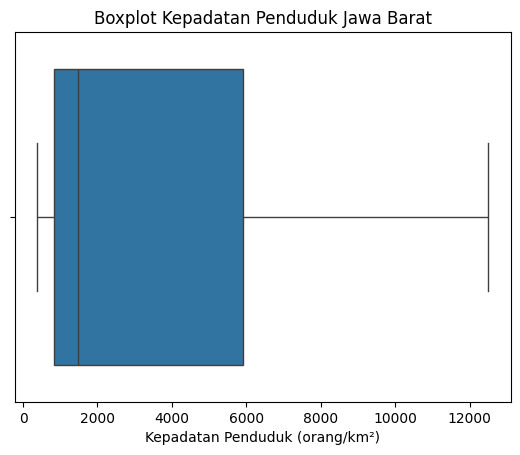

In [ ]:
#Handling outliers data kependudukan dengan boxplot

upper_limit = 12500

df_penduduk_clean['kepadatan_penduduk'] = df_penduduk_clean['kepadatan_penduduk'].clip(upper=upper_limit)

sns.boxplot(x=df_penduduk_clean['kepadatan_penduduk'])
plt.title('Boxplot Kepadatan Penduduk Jawa Barat')
plt.xlabel('Kepadatan Penduduk (orang/km²)')
plt.show()


In [ ]:
geolocator = Nominatim(user_agent="geo_helper")

def get_city(lat, lon):
    try:
        time.sleep(1)
        location = geolocator.reverse((lat, lon), timeout=10)
        address = location.raw['address']
        return address.get('city', address.get('town', address.get('county', ''))).upper()
    except:
        return None
    
print("Mengambil nama kabupaten dari koordinat...")
df_final['nama_kabupaten_kota'] = df_final.apply(lambda x: get_city(x.lat, x.lon), axis=1)

Mengambil nama kabupaten dari koordinat...


In [ ]:
#Integrasi inti menggunakan algoritma radius searching 

#pisah data per kategori untuk memudahkan proses radius searching
school = np.deg2rad(df_final[df_final['kategori'] == 'sekolah'][['lat', 'lon']].values)
campus = np.deg2rad(df_final[df_final['kategori'] == 'kampus'][['lat', 'lon']].values)
restaurant = np.deg2rad(df_final[df_final['kategori'] == 'restoran'][['lat', 'lon']].values)
market = np.deg2rad(df_final[df_final['kategori'] == 'pasar'][['lat', 'lon']].values)

#Ball tree
tree_school = BallTree(school, metric='haversine')
tree_campus = BallTree(campus, metric='haversine')
tree_restaurant = BallTree(restaurant, metric='haversine')
tree_market = BallTree(market, metric='haversine')

def count_near_facility(lat, lon, radius_km=1.0):
    radius_rad = radius_km / 6371
    point = np.deg2rad([[lat, lon]])

    count_school = tree_school.query_radius(point, r=radius_rad, count_only=True)[0]
    count_campus = tree_campus.query_radius(point, r=radius_rad, count_only=True)[0]
    count_restaurant = tree_restaurant.query_radius(point, r=radius_rad, count_only=True)[0]
    count_market = tree_market.query_radius(point, r=radius_rad, count_only=True)[0]

    return count_school, count_campus, count_restaurant, count_market


#integrasi koordinat ke data penduduk

def create_dataset_per_titik(df_koordinat, df_bps):
    if 'nama_kabupaten_kota' not in df_koordinat.columns:
        raise ValueError("Error: Kolom 'nama_kabupaten_kota' belum ada di data koordinat!")
    
    
    print("menghitung fasilitas per titik ...")
    res = df_koordinat.apply(lambda x: count_near_facility(x.lat, x.lon), axis=1)

    df_koordinat['jml_sekolah'] = [r[0] for r in res]
    df_koordinat['jml_campus']  = [r[1] for r in res]
    df_koordinat['jml_restoran'] = [r[2] for r in res]
    df_koordinat['jml_market']   = [r[3] for r in res]

    print("Menggabungkan data kependudukan wilayah...")
    df_hasil_akhir = df_koordinat.merge(
        df_bps[['nama_kabupaten_kota', 'kepadatan_penduduk']],
        on='nama_kabupaten_kota',
        how='left'
    )

    return df_hasil_akhir

dataset_per_titik = create_dataset_per_titik(df_final, df_penduduk_clean)
dataset_per_titik.to_csv("dataset_per_koordinat_jabar.csv", index=False)





menghitung fasilitas per titik ...
Menggabungkan data kependudukan wilayah...


KeyError: 'nama_kabupaten_kota'

In [11]:
def tentukan_kabkota(lat, lon):
    # Bandung & sekitarnya
    if -7.0 <= lat <= -6.8 and 107.5 <= lon <= 107.7:
        return "KOTA BANDUNG"
    # Bogor & sekitarnya
    elif -6.7 <= lat <= -6.4 and 106.7 <= lon <= 106.9:
        return "KABUPATEN BOGOR"
    # Bekasi & sekitarnya
    elif -6.4 <= lat <= -6.1 and 106.9 <= lon <= 107.1:
        return "KOTA BEKASI"
    # Cianjur & sekitarnya
    elif -7.4 <= lat <= -7.1 and 107.0 <= lon <= 107.3:
        return "KABUPATEN CIANJUR"
    else:
        return "JAWA BARAT" # Default kalau di luar jangkauan box di atas

# Terapkan langsung ke df_final
df_final['nama_kabupaten_kota'] = df_final.apply(lambda x: tentukan_kabkota(x.lat, x.lon), axis=1)

# Cek hasilnya
print(df_final['nama_kabupaten_kota'].value_counts())

nama_kabupaten_kota
JAWA BARAT           13826
KABUPATEN BOGOR       3631
KOTA BANDUNG          1939
KOTA BEKASI           1719
KABUPATEN CIANJUR       12
Name: count, dtype: int64
